<a href="https://colab.research.google.com/github/Kurniangga/Jobsheet02_Klasifikasi_Gambar/blob/main/Jobsheet02_Klasifikasi_Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum D1 – Memulai Klasifikasi Gambar dengan Dataset Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


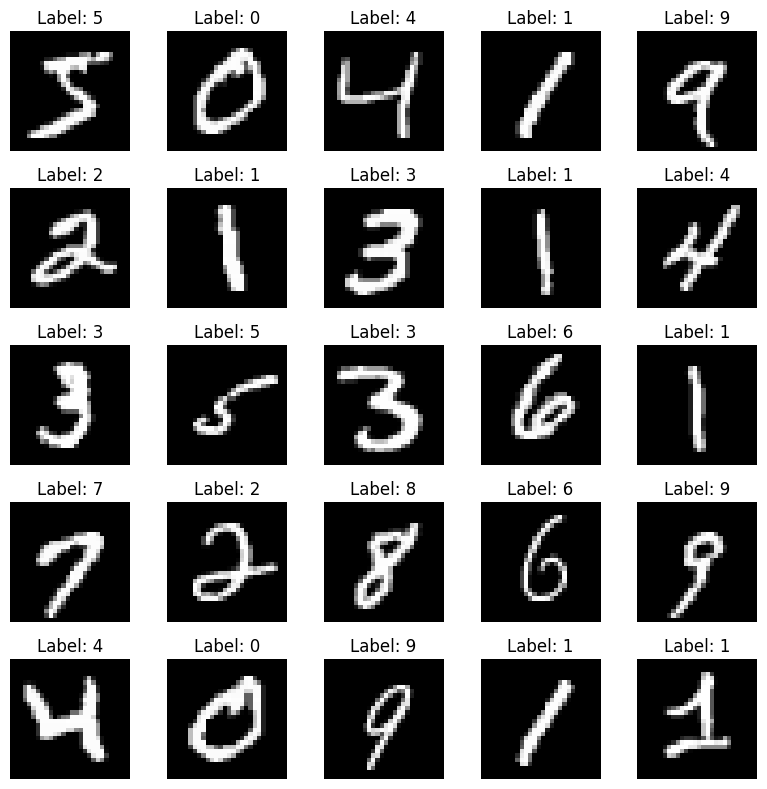

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Bentuk x_train:", x_train.shape)   # (60000, 28, 28) -> 60000 gambar 28x28
print("Bentuk y_train:", y_train.shape)   # (60000,) -> 60000 label
print("Bentuk x_test :", x_test.shape)    # (10000, 28, 28)
print("Nilai piksel min-max:", x_train.min(), "-", x_train.max())  # 0 - 255

# Normalisasi: ubah skala piksel 0-255 menjadi 0-1 supaya model lebih mudah belajar
x_train_norm = x_train / 255.0
print("Setelah normalisasi:", x_train_norm.min(), "-", x_train_norm.max())

Bentuk x_train: (60000, 28, 28)
Bentuk y_train: (60000,)
Bentuk x_test : (10000, 28, 28)
Nilai piksel min-max: 0 - 255
Setelah normalisasi: 0.0 - 1.0


Praktikum D2: SVM (cara klasik)

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten + normalisasi
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat  = x_test.reshape(len(x_test), -1) / 255.0

# SVM linear (gunakan subset 5000 data karena SVM berat)
clf_rbf = svm.SVC(kernel='rbf', gamma='scale')
clf_rbf.fit(x_train_flat[:5000], y_train[:5000])

y_pred_rbf = clf_rbf.predict(x_test_flat)
print("Akurasi SVM rbf   :", accuracy_score(y_test, y_pred_rbf))

Akurasi SVM rbf   : 0.9513


In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten + normalisasi
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat  = x_test.reshape(len(x_test), -1) / 255.0

# SVM linear (gunakan subset 5000 data karena SVM berat)
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])

y_pred = clf.predict(x_test_flat)
print("Akurasi SVM linear:", accuracy_score(y_test, y_pred))

Akurasi SVM linear: 0.9101


Praktikum D3: CNN sederhana (MNIST)

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, judul):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{judul} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{judul} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9464 - loss: 0.1782 - val_accuracy: 0.9760 - val_loss: 0.0782
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9812 - loss: 0.0626 - val_accuracy: 0.9845 - val_loss: 0.0556
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0413 - val_accuracy: 0.9868 - val_loss: 0.0505
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.9853 - val_loss: 0.0583
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.9878 - val_loss: 0.0481


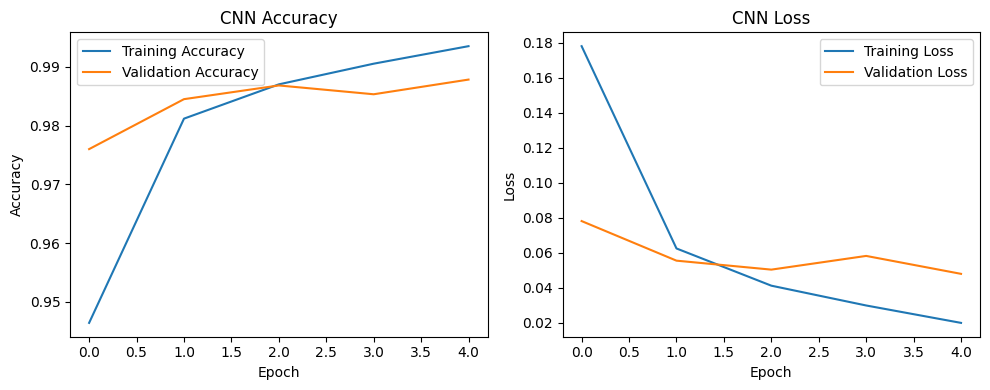

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Ubah bentuk jadi [samples, height, width, channels] + normalisasi
x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn  = x_test.reshape(-1,28,28,1) / 255.0

model_cnn = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = model_cnn.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

plot_history(history_cnn, 'CNN')

In [ ]:
loss, acc = model_cnn.evaluate(x_test_cnn, y_test)
print(f"Akurasi test CNN D3: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0474
Akurasi test CNN D3: 0.9862


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9539 - loss: 0.1469 - val_accuracy: 0.9863 - val_loss: 0.0453
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9857 - loss: 0.0474 - val_accuracy: 0.9875 - val_loss: 0.0420
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9890 - val_loss: 0.0370
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9908 - val_loss: 0.0381
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9882 - val_loss: 0.0460


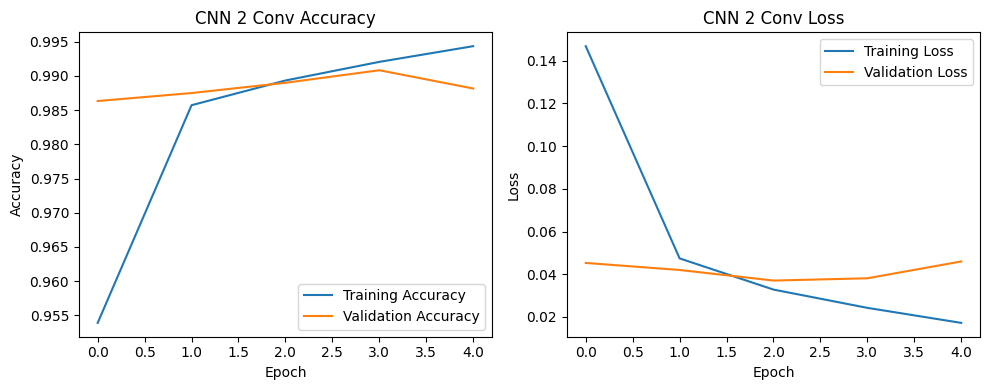

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0348
Akurasi test CNN (2 Conv): 0.9882


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Ubah bentuk jadi [samples, height, width, channels] + normalisasi
x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn  = x_test.reshape(-1,28,28,1) / 255.0

model_cnn2 = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),   # <- lapisan tambahan
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn2.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_cnn2 = model_cnn2.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)
plot_history(history_cnn2, 'CNN 2 Conv')

loss2, acc2 = model_cnn2.evaluate(x_test_cnn, y_test)
print(f"Akurasi test CNN (2 Conv): {acc2:.4f}")

D4 – CNN dengan Dataset CIFAR-10 (RGB)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1362s 8us/step
Bentuk x_train_c: (50000, 32, 32, 3)
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4670 - loss: 1.4763 - val_accuracy: 0.5564 - val_loss: 1.2367
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5998 - loss: 1.1427 - val_accuracy: 0.6348 - val_loss: 1.0668
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6457 - loss: 1.0165 - val_accuracy: 0.6564 - val_loss: 0.9788
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6736 - loss: 0.9303 - val_accuracy: 0.6774 - val_loss: 0.9323
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6969 - loss: 0.8673 - val_accuracy: 0.6806 - val_loss: 0.9302
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7175 - loss: 0.8125 - val_accuracy: 0.6934 - val_loss: 0.9113
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7355 - loss: 0.7627 - val_accuracy: 0.6930 - val_loss: 0.9

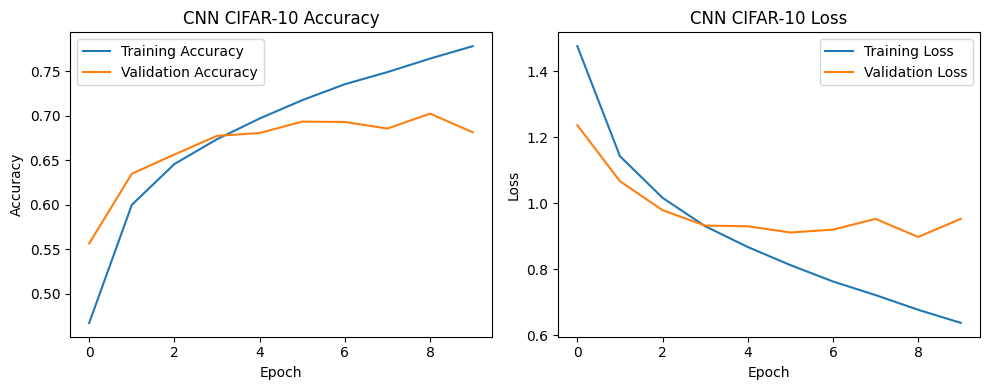

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6739 - loss: 1.0009
Akurasi test CIFAR-10: 0.6739


In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c/255.0, x_test_c/255.0

print("Bentuk x_train_c:", x_train_c.shape)   # (50000, 32, 32, 3) -> 3 = kanal warna RGB

model_cifar = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_cifar = model_cifar.fit(x_train_c, y_train_c, epochs=10, validation_split=0.1)

plot_history(history_cifar, 'CNN CIFAR-10')

loss, acc = model_cifar.evaluate(x_test_c, y_test_c)
print(f"Akurasi test CIFAR-10: {acc:.4f}")

Bentuk x_train_c: (50000, 32, 32, 3)
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3627 - loss: 1.7230 - val_accuracy: 0.5104 - val_loss: 1.3645
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4775 - loss: 1.4397 - val_accuracy: 0.5652 - val_loss: 1.2639
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5199 - loss: 1.3265 - val_accuracy: 0.6100 - val_loss: 1.0979
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5498 - loss: 1.2486 - val_accuracy: 0.6186 - val_loss: 1.0998
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5789 - loss: 1.1814 - val_accuracy: 0.6536 - val_loss: 0.9952
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5996 - loss: 1.1224 - val_accuracy: 0.6622 - val_loss: 0.9647
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6179 - loss: 1.0740 - val_accuracy: 0.6700 - val_loss: 0.9334
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/ste

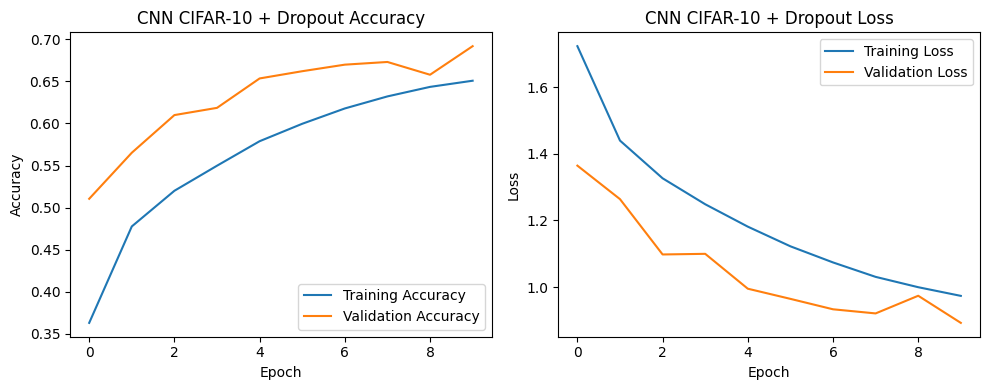

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6834 - loss: 0.9186
Akurasi test CIFAR-10 + Dropout: 0.6834


In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c/255.0, x_test_c/255.0

print("Bentuk x_train_c:", x_train_c.shape)   # (50000, 32, 32, 3) -> 3 = kanal warna RGB

model_cifar_do = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),                            # <- ditambahkan
    layers.Dense(10, activation='softmax')
])

model_cifar_do.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_cifar_do = model_cifar_do.fit(x_train_c, y_train_c, epochs=10, validation_split=0.1)
plot_history(history_cifar_do, 'CNN CIFAR-10 + Dropout')

loss, acc = model_cifar_do.evaluate(x_test_c, y_test_c)
print(f"Akurasi test CIFAR-10 + Dropout: {acc:.4f}")

D5 – Transfer Learning (VGG16/ResNet50)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.5181 - loss: 1.3830 - val_accuracy: 0.5726 - val_loss: 1.2343
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5818 - loss: 1.1977 - val_accuracy: 0.5898 - val_loss: 1.1698
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6014 - loss: 1.1429 - val_accuracy: 0.5976 - val_loss: 1.1374
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6140 - loss: 1.1047 - val_accuracy: 0.6076 - val_loss: 1.1234
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6259 - loss: 1.0706 - val_accuracy: 0.6042 - val_loss: 1.1275


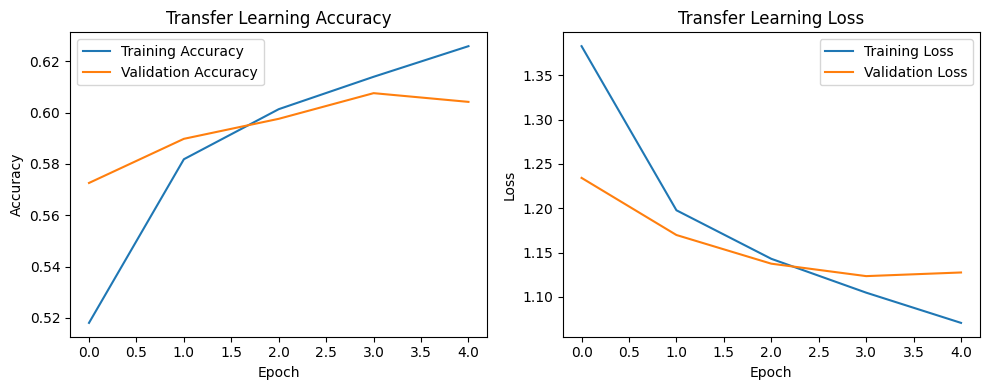

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5961 - loss: 1.1583
Akurasi test VGG16 (frozen): 0.5961


In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False   # bekukan lapisan konvolusi

model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_vgg.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_vgg = model_vgg.fit(x_train_c, y_train_c, epochs=5, validation_split=0.1)

plot_history(history_vgg, 'Transfer Learning')

loss, acc = model_vgg.evaluate(x_test_c, y_test_c)
print(f"Akurasi test VGG16 (frozen): {acc:.4f}")

Praktikum D6: Confusion matrix dan metrik lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

    airplane       0.62      0.75      0.68      1000
  automobile       0.74      0.54      0.63      1000
        bird       0.58      0.42      0.49      1000
         cat       0.46      0.41      0.43      1000
        deer       0.56      0.53      0.54      1000
         dog       0.64      0.44      0.52      1000
        frog       0.54      0.77      0.63      1000
       horse       0.64      0.67      0.65      1000
        ship       0.70      0.72      0.71      1000
       truck       0.54      0.72      0.62      1000

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.59     10000
weighted avg       0.60      0.60      0.59     10000



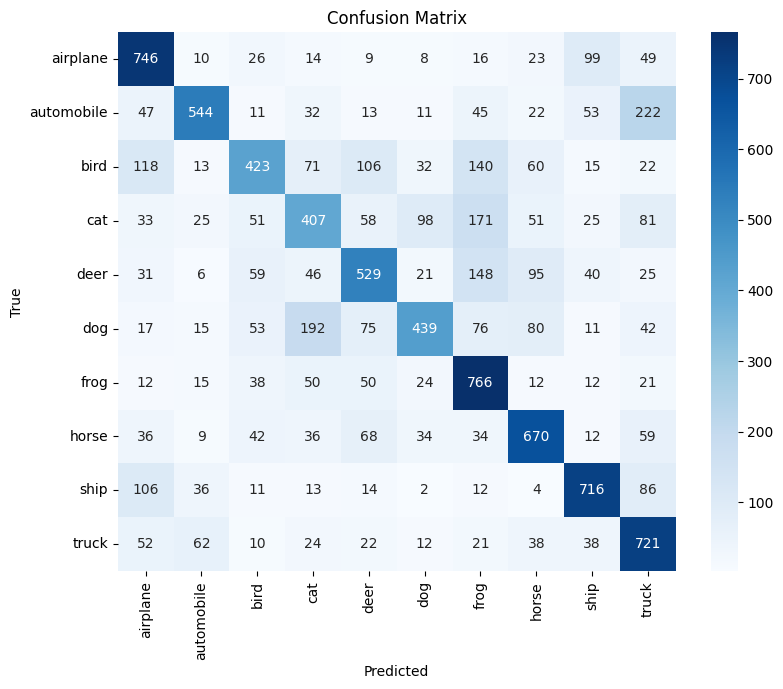

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

nama_kelas = ['airplane','automobile','bird','cat','deer',
              'dog','frog','horse','ship','truck']

y_pred = model_vgg.predict(x_test_c).argmax(axis=1)
y_true = y_test_c.flatten()

print(classification_report(y_true, y_pred, target_names=nama_kelas))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas, yticklabels=nama_kelas)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Penugasan (Pilihan B) Prediksi dengan SVM dari D2

In [ ]:
from google.colab import files
uploaded = files.upload()  # pilih ketiga file: 2.jpg, 5.jpg, 7.jpg sekaligus

Saving sampel(1).jpeg to sampel(1).jpeg
Saving sampel_6.png to sampel_6.png
Saving sampel_2.jpeg to sampel_2.jpeg


In [ ]:
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    arr = np.array(canvas).astype('float32') / 255.0
    arr = arr[..., None]
    return canvas, arr

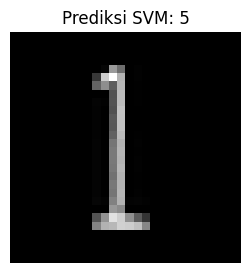

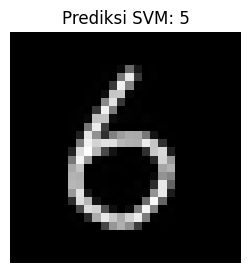

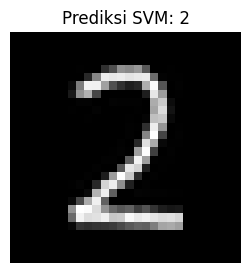

Rekap Prediksi (SVM):
- sampel(1).jpeg -> 5
- sampel_6.png -> 5
- sampel_2.jpeg -> 2


In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)
    x_flat = x.reshape(1, -1)

    pred = int(clf.predict(x_flat)[0])

    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    results.append((fname, pred, conf))

    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    judul = f"Prediksi SVM: {pred}"
    if conf is not None:
        judul += f" (p={conf:.2f})"
    plt.title(judul)
    plt.axis('off')
    plt.show()

print("Rekap Prediksi (SVM):")
for r in results:
    if r[2] is not None:
        print(f"- {r[0]} -> {r[1]} (p≈{r[2]:.2f})")
    else:
        print(f"- {r[0]} -> {r[1]}")

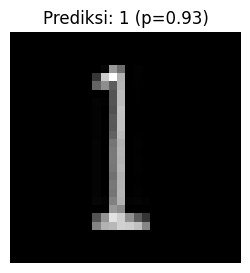

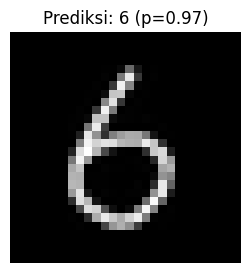

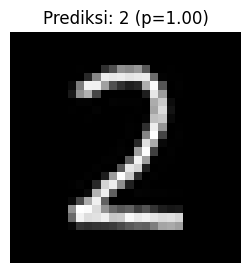

Rekap Prediksi (CNN):
- sampel(1).jpeg -> 1 (p=0.929)
- sampel_6.png -> 6 (p=0.968)
- sampel_2.jpeg -> 2 (p=1.000)


In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)  # disp: PIL untuk ditampilkan, x: (28,28,1)
    disp, x = preprocess_to_mnist_28x28(img_pil)
    x_batch = np.expand_dims(x, axis=0)  # (1,28,28,1)

    probs = model_cnn.predict(x_batch, verbose=0)[0]  # shape (10,)
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))
    results.append((fname, pred, conf))

    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred} (p={conf:.2f})")
    plt.axis('off')
    plt.show()

print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

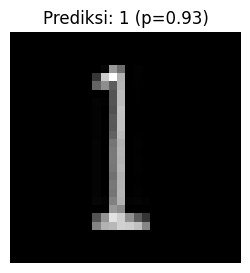

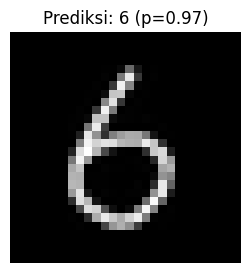

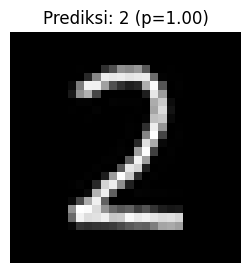

Rekap Prediksi (CNN):
- sampel(1).jpeg -> 1 (p=0.929)
- sampel_6.png -> 6 (p=0.968)
- sampel_2.jpeg -> 2 (p=1.000)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)  # disp: PIL untuk ditampilkan, x: (28,28,1)
    x_batch = np.expand_dims(x, axis=0)             # (1,28,28,1)

    probs = model_cnn.predict(x_batch, verbose=0)[0]  # shape (10,)
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))
    results.append((fname, pred, conf))

    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred} (p={conf:.2f})")
    plt.axis('off')
    plt.show()

print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")